# Lag-1 Baseline Analysis

Analyze the lag-1 forecasting baseline to understand where it performs well or poorly and how demand characteristics relate to forecast error.

## Recreate Baseline Evaluation

Recreate the key datasets from the previous forecasting notebook needed for further analysis:

- Load the processed item-store-day data.
- Recreate the lag-1 predictions and 365-day evaluation period.
- Recreate the item-store summary metrics used to evaluate baseline performance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from data.loader import load_raw_m5_data
from data.pipeline import build_item_store_day
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

RAW_DATA_PATH = Path("../data/raw")

In [2]:
item_store_day = build_item_store_day(*load_raw_m5_data(RAW_DATA_PATH))

In [3]:
forecasting_baseline = item_store_day[
    ["item_id", "store_id", "d", "date", "units_sold"]
].copy()

forecasting_baseline["predicted_units_sold"] = (
    forecasting_baseline
    .groupby(["item_id", "store_id"])["units_sold"]
    .shift(1)
)

In [4]:
# Check 365-day evaluation period
# 1913 - 365 + 1 = 1549
evaluation = forecasting_baseline[
    forecasting_baseline["d"] >= 1549
].copy()

evaluation["error_abs"] = abs(
    evaluation["predicted_units_sold"] - evaluation["units_sold"]
)

In [5]:
item_store_summary = (
    evaluation
    .groupby(["item_id", "store_id"])
    .agg(
        mean_demand=("units_sold", "mean"),
        demand_sd=("units_sold", "std"),
        demand_mae=("error_abs", "mean"),
    )
    .reset_index()
)

In [6]:
rmse_df = (
    evaluation
    .groupby(["item_id", "store_id"])[["units_sold", "predicted_units_sold"]]
    .apply(
        lambda group: root_mean_squared_error(
            group["units_sold"],
            group["predicted_units_sold"],
        )
    )
    .rename("demand_rmse")
    .reset_index()
)

item_store_summary = item_store_summary.merge(
    rmse_df,
    on=["item_id", "store_id"],
)

item_store_summary["mae_rel"] = (
    item_store_summary["demand_mae"]
    / item_store_summary["mean_demand"]
)

## Baseline Performance Analysis

With the lag-1 baseline evaluation recreated, begin analyzing how demand characteristics relate to forecast performance and where the baseline performs well or poorly.

In [7]:
evaluation.head(3)

,item_id,store_id,d,date,units_sold,predicted_units_sold,error_abs
47198520,HOBBIES_1_001,CA_1,1549,2015-04-26,0,2.0,2.0
47198521,HOBBIES_1_002,CA_1,1549,2015-04-26,0,0.0,0.0
47198522,HOBBIES_1_003,CA_1,1549,2015-04-26,0,0.0,0.0


In [8]:
len(evaluation[["item_id", "store_id", "d"]]) == len(evaluation[["item_id", "store_id", "d"]].drop_duplicates())

True

In [9]:
item_store_summary.head(3)

,item_id,store_id,mean_demand,demand_sd,demand_mae,demand_rmse,mae_rel
0,FOODS_1_001,CA_1,0.673973,1.013918,1.013699,1.498858,1.504065
1,FOODS_1_001,CA_2,0.980822,1.674687,1.364384,2.398630,1.391061
2,FOODS_1_001,CA_3,0.978082,2.382298,1.558904,3.382874,1.593838


In [10]:
zero_demand = (
    evaluation
    .groupby(["item_id", "store_id"])["units_sold"]
    .apply(lambda group: (group == 0).sum() / len(group))
    .rename("zero_demand_rate")
    .reset_index()
)

item_store_summary = pd.merge(
    item_store_summary,
    zero_demand,
    on=["item_id", "store_id"],
    validate="one_to_one",
)

In [11]:
item_store_summary["zero_demand_rate"].describe()

count    30490.000000
mean         0.597110
std          0.252365
min          0.000000
25%          0.413699
50%          0.641096
75%          0.808219
max          1.000000
Name: zero_demand_rate, dtype: float64

In [12]:
(
    len(item_store_summary[["item_id", "store_id"]])
    == len(item_store_summary[["item_id", "store_id"]].drop_duplicates())
)

True

In [13]:
# What percentage of the 30,490 item-store pairs have zero_demand_rate >= 0.50?
pctg = (
    len(item_store_summary[item_store_summary["zero_demand_rate"] >= 0.5])
    / len(item_store_summary)
) * 100
print(f"{pctg}% of the 30,490 item-store pairs have zero_demand_rate >= 0.50")
del pctg

66.59888488028862% of the 30,490 item-store pairs have zero_demand_rate >= 0.50


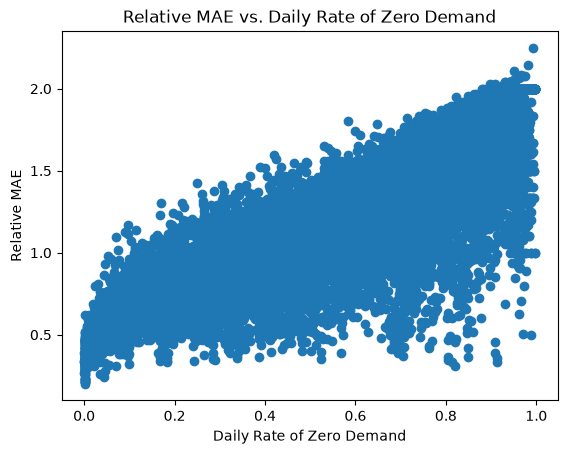

In [14]:
plt.scatter(
    item_store_summary["zero_demand_rate"],
    item_store_summary["mae_rel"]
)

plt.xlabel("Daily Rate of Zero Demand")
plt.ylabel("Relative MAE")
plt.title("Relative MAE vs. Daily Rate of Zero Demand");

### Investigate Demand-State Switching

Lag-1 forecasts may perform poorly when demand frequently switches between zero and nonzero values. A nonzero sales day surrounded by zero-demand days can produce errors both when demand appears and when it returns to zero.

Measure how frequently each item-store pair switches between zero and nonzero demand and examine how this relates to relative MAE.

In [15]:
demand_switch_rate = (
    evaluation
    .groupby(["item_id", "store_id"])["units_sold"]
    .apply(
        lambda group: (
            (group.eq(0) != group.shift(1).eq(0)).iloc[1:]
        ).mean()
    )
    .rename("demand_switch_rate")
    .reset_index()
)

item_store_summary = pd.merge(
    item_store_summary,
    demand_switch_rate,
    on=["item_id", "store_id"],
    validate="one_to_one",
)

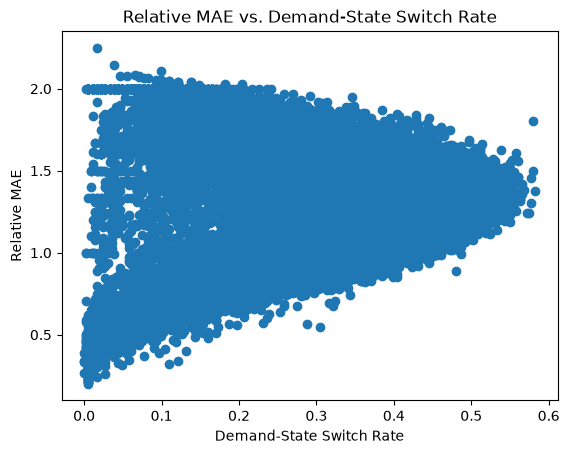

In [16]:
plt.scatter(
    item_store_summary["demand_switch_rate"],
    item_store_summary["mae_rel"],
)

plt.xlabel("Demand-State Switch Rate")
plt.ylabel("Relative MAE")
plt.title("Relative MAE vs. Demand-State Switch Rate");

In [17]:
valid_mae_rel = item_store_summary[
    item_store_summary["mae_rel"].notna()
]

best_mae_rel = valid_mae_rel.sort_values("mae_rel").head(5)

worst_mae_rel = valid_mae_rel.sort_values(
    "mae_rel",
    ascending=False,
).head(5)

In [18]:
best_mae_rel

,item_id,store_id,mean_demand,demand_sd,demand_mae,demand_rmse,mae_rel,zero_demand_rate,demand_switch_rate
11982,FOODS_3_586,CA_3,73.580822,18.925742,14.821918,19.471229,0.201437,0.00274,0.005495
11986,FOODS_3_586,TX_3,73.509589,20.687710,15.361644,21.003392,0.208975,0.00274,0.005495
8388,FOODS_3_226,WI_2,38.879452,10.754592,8.317808,10.781262,0.213938,0.00274,0.005495
11985,FOODS_3_586,TX_2,92.504110,26.944349,19.854795,27.083483,0.214637,0.00274,0.005495
8389,FOODS_3_226,WI_3,48.084932,12.539867,10.517808,13.889880,0.218734,0.00274,0.005495


In [19]:
worst_mae_rel

,item_id,store_id,mean_demand,demand_sd,demand_mae,demand_rmse,mae_rel,zero_demand_rate,demand_switch_rate
23007,HOUSEHOLD_1_305,WI_1,0.010959,0.127918,0.024658,0.188723,2.250000,0.991781,0.016484
18538,HOBBIES_2_001,WI_2,0.019178,0.137339,0.041096,0.202721,2.142857,0.980822,0.038462
25718,HOUSEHOLD_2_038,WI_2,0.052055,0.234468,0.109589,0.355003,2.105263,0.950685,0.098901
25987,HOUSEHOLD_2_065,WI_1,0.032877,0.178559,0.068493,0.261712,2.083333,0.967123,0.065934
373,FOODS_1_039,CA_4,0.035616,0.248827,0.073973,0.366397,2.076923,0.975342,0.046703


In [20]:
best_pair = best_mae_rel.iloc[0]
worst_pair = worst_mae_rel.iloc[0]

best_evaluation = evaluation[
    (evaluation["item_id"] == best_pair["item_id"])
    & (evaluation["store_id"] == best_pair["store_id"])
]

worst_evaluation = evaluation[
    (evaluation["item_id"] == worst_pair["item_id"])
    & (evaluation["store_id"] == worst_pair["store_id"])
]

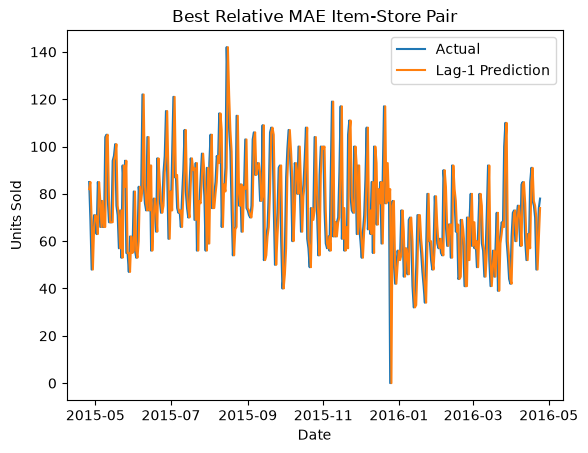

In [21]:
plt.plot(
    best_evaluation["date"],
    best_evaluation["units_sold"],
    label="Actual",
)

plt.plot(
    best_evaluation["date"],
    best_evaluation["predicted_units_sold"],
    label="Lag-1 Prediction",
)

plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.title("Best Relative MAE Item-Store Pair")
plt.legend();

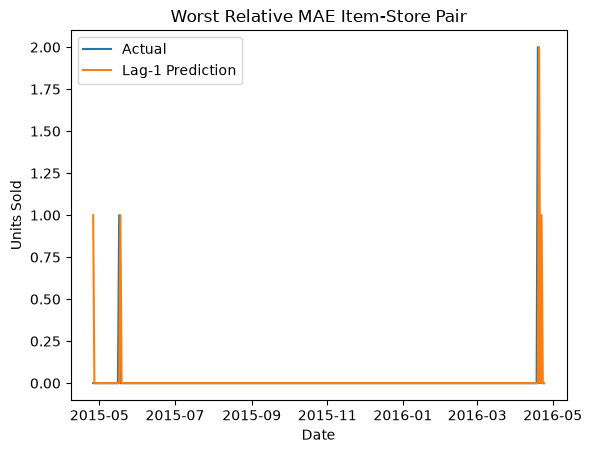

In [22]:
plt.plot(
    worst_evaluation["date"],
    worst_evaluation["units_sold"],
    label="Actual",
)

plt.plot(
    worst_evaluation["date"],
    worst_evaluation["predicted_units_sold"],
    label="Lag-1 Prediction",
)

plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.title("Worst Relative MAE Item-Store Pair")
plt.legend();

### Findings

The lag-1 baseline performs well for item-store pairs with relatively continuous demand, where the previous day's sales provide a useful approximation of the next day's sales.

Performance is much worse for highly intermittent demand. When sales occur only occasionally among long periods of zero demand, lag-1 tends to miss the sales event and then predict that demand one day too late.

Demand sparsity is associated with higher relative forecast error, although neither zero-demand rate nor demand-state switch rate alone fully explains baseline performance.